# L10 Pipelines
Code given:

In [236]:
%matplotlib inline

import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def LoadDataFromL01():
    filename = "Data/itmal_l01_data.pkl"
    with open(f"{filename}", "rb") as f:
        (X, y) = pickle.load(f)
        return X, y

X, y = LoadDataFromL01()

print(f"X.shape={X.shape},  y.shape={y.shape}")

assert X.shape[0] == y.shape[0]
assert X.ndim == 2
assert y.ndim == 1  # did a y.ravel() before saving to picke file
assert X.shape[0] == 29

# re-create plot data (not stored in the Pickel file)
m = np.linspace(0, 60000, 1000)
M = np.empty([m.shape[0], 1])
M[:, 0] = m

print("OK")

X.shape=(29, 1),  y.shape=(29,)
OK


C:\Users\bruger\AppData\Local\Temp\ipykernel_14948\3445365470.py:15: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  (X, y) = pickle.load(f)


The MLP may mis-fit the data, seen in the, sometimes, bad R^2 score..

lin.reg.score(X, y)=0.73
    MLP.score(X, y)=-135663.72

OK


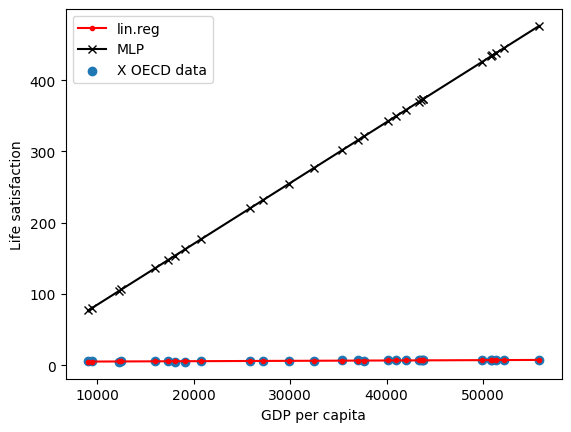

In [237]:
def isNumpyData(t: np.ndarray, expected_ndim: int):
    assert isinstance(expected_ndim, int), f"input parameter 'expected_ndim' is not an integer but a '{type(expected_ndim)}'"
    assert expected_ndim>=0, f"expected input parameter 'expected_ndim' to be >=0, got {expected_ndim}"
    if t is None:
        print("input parameter 't' is None", file=sys.stderr)
        return False
    if not isinstance(t, np.ndarray):
        print("excepted numpy.ndarray got type '{type(t)}'", file=sys.stderr)
        return False
    if not t.ndim==expected_ndim:
        print("expected ndim={expected_ndim} but found {t.ndim}", file=sys.stderr)
        return False
    return True

def PlotModels(model1, model2, X: np.ndarray, y: np.ndarray, name_model1: str, name_model2: str):
    
    # NOTE: local function is such a nifty feature of Python!
    def CalcPredAndScore(model, X: np.ndarray, y: np.ndarray,):
        assert isNumpyData(X, 2) and isNumpyData(y, 1) and X.shape[0]==y.shape[0]
        y_pred_model = model.predict(X)
        score_model = r2_score(y, y_pred_model) # call r2
        return y_pred_model, score_model    

    assert isinstance(name_model1, str) and isinstance(name_model2, str)

    y_pred_model1, score_model1 = CalcPredAndScore(model1, X, y)
    y_pred_model2, score_model2 = CalcPredAndScore(model2, X, y)

    plt.plot(X, y_pred_model1, "r.-")
    plt.plot(X, y_pred_model2, "kx-")
    plt.scatter(X, y)
    plt.xlabel("GDP per capita")
    plt.ylabel("Life satisfaction")
    plt.legend([name_model1, name_model2, "X OECD data"])

    l = max(len(name_model1), len(name_model2))
    
    print(f"{(name_model1).rjust(l)}.score(X, y)={score_model1:0.2f}")
    print(f"{(name_model2).rjust(l)}.score(X, y)={score_model2:0.2f}")

# lets make a linear and MLP regressor and redo the plots
mlp = MLPRegressor(hidden_layer_sizes=(10, ),
                   solver='adam',
                   activation='relu',
                   tol=1E-5,
                   max_iter=100000,
                   verbose=False)
linreg = LinearRegression()

mlp.fit(X, y)
linreg.fit(X, y)

print("The MLP may mis-fit the data, seen in the, sometimes, bad R^2 score..\n")
PlotModels(linreg, mlp, X, y, "lin.reg", "MLP")
print("\nOK")

### Qa Create a Min/max scaler for the MLP
The MLP usually expects values in the |1| range and so we should "normalize" the data with a scaler which is what is done here below:

In [238]:
norm_X = np.linalg.norm(X)

# Divide to get the unit vector
X_scaled = X/norm_X
assert (X_scaled <= 1).all()
# Setup MLPRegressor
mlp_scaled = MLPRegressor( hidden_layer_sizes=(10,), solver='adam', activation='relu', tol=1E-5, max_iter=100000, verbose=False)
mlp_scaled.fit(X_scaled, y)
scaled_score = mlp_scaled.score(X_scaled,y)
print("R2 = ",scaled_score)
print("Clearly much better this time around\nOK")

# We are asked to manually scale X to be between 0 and 1 which i have done but the header says a min maxer so that is implemented below
X_scaled = (X - min(X))/(max(X)-min(X))
assert (X_scaled <= 1).all()
# Setup MLPRegressor
mlp_scaled = MLPRegressor( hidden_layer_sizes=(10,), solver='adam', activation='relu', tol=1E-5, max_iter=100000, verbose=False)
mlp_scaled.fit(X_scaled, y)
scaled_score = mlp_scaled.score(X_scaled,y)
print("R2 = ",scaled_score)
print("About the same as the unit approach\nOK")

R2 =  0.7179732182539813
Clearly much better this time around
OK
R2 =  0.7254365933623266
About the same as the unit approach
OK


### Qb Scikit-learn Pipelines


In [239]:
# Initialize the scaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
assert (X_scaled <= 1).all()
minMaxMLP = MLPRegressor( hidden_layer_sizes=(10,), solver='adam', activation='relu', tol=1E-5, max_iter=100000, verbose=False)

minMaxMLP.fit(X_scaled, y)
minMax_score = minMaxMLP.score(X_scaled,y)
print("R2 = ",minMax_score)
print("Not a clear difference in the score between the two scaled versions, although the MinMax seems somewhat faster than the linear algebra approach\nOK")

R2 =  0.7264268967207181
Not a clear difference in the score between the two scaled versions, although the MinMax seems somewhat faster than the linear algebra approach
OK


lin.reg.score(X, y)=0.73
    MLP.score(X, y)=0.77
Very clean looking and it works!
OK


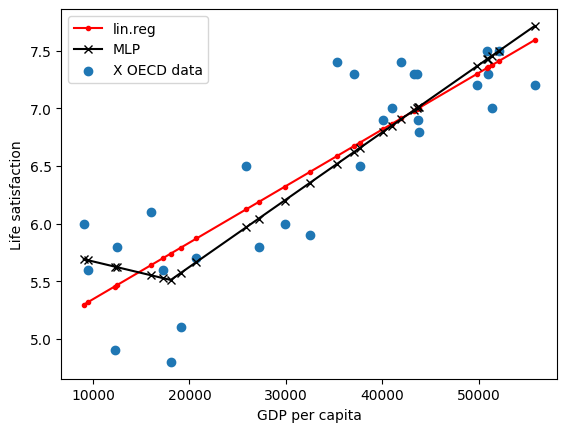

In [240]:
# Now for the pipelining
from sklearn.pipeline import Pipeline
pipeMLP = Pipeline([
    ('scaler', MinMaxScaler()),
    ('mlp', MLPRegressor(hidden_layer_sizes=(10,), solver='lbfgs', max_iter=10000))
])

pipeMLP.fit(X,y)
pipeMLP.score(X,y)
PlotModels(linreg, pipeMLP, X, y, "lin.reg", "MLP")
print("Very clean looking and it works!\nOK")


# Qc
### Outliers and the Min-max Scaler vs. the Standard Scaler
Since the min-max scaler works by using the formula $x_{scaled} = \frac{x-min(X)}{max(X)-min(X)}$, which clearly shows that a MinMax scaler can be heavily skewed by a single outlier, either to values relatively to high or low. If max(X) is far greater than the next biggest value in X this will misrepresent the data once scaled. A standaes scaler instead functions by $x_{scaled} = \frac{x-x_{mean}}{x_{standardDeviation}}$, which is an approach that is more robust and in a greater sense takes the whole dataset into consideration.

### Qd Modify the MLP Hyperparameters

In [241]:
print("n, current_score")
for n in range(2, 11):
    # 1. Initialize model with n neurons in 1 hidden layer
    mlp = MLPRegressor(hidden_layer_sizes=(n,), solver='lbfgs', max_iter=10000)
    
    # 2. Fit the model
    mlp.fit(X_scaled, y)
    
    # 3. Calculate the score
    current_score = mlp.score(X_scaled, y)
    
    # 4. Print results
    print(n, current_score)
print("We see that for n>2 the mlp most of the time returns usable scores, when run a couple of times n values up to 7 produces negative scores though")

n, current_score
2 0.7344414353058631
3 0.7344414349850926
4 0.7344414354352837
5 0.7344414211643752
6 0.7344414350263119
7 0.812285230475843
8 0.7344414105711117
9 0.734441350134227
10 0.7673228023865772
We see that for n>2 the mlp most of the time returns usable scores, when run a couple of times n values up to 7 produces negative scores though


In [242]:
# MLP only uses early stop for sgd or ADAMS method, ADAMS is default
MLPADAM = MLPRegressor(hidden_layer_sizes=(10,), max_iter=10000)
MLPADAM.fit(X_scaled, y)
EarlyStopScore = MLPADAM.score(X_scaled, y)
print(EarlyStopScore)

print("n, current_score")
for n in range(1, 11):
    MLPEarly = MLPRegressor(hidden_layer_sizes=(n,), max_iter=10000, early_stopping= True)
    MLPEarly.fit(X_scaled, y)
    EarlyStopScoren = MLPEarly.score(X_scaled, y)
    print(n,   EarlyStopScoren)
print("it is hard to descipher how much the early stopping interferes but it is clear that the ADAM solver is not well suited for this dataset\nIt is generally better for large datasets where the lbfgs is better for smaller sets like the one used here")

0.5306495511592128
n, current_score
1 -0.013946950765975075
2 0.42203023202282675
3 -2.6236251579641334
4 0.09930837670813564
5 0.6810248234864043
6 0.03795647081000042
7 0.34341941965975
8 0.7312125371603321
9 -0.4626648315803832
10 0.6473818017141123
it is hard to descipher how much the early stopping interferes but it is clear that the ADAM solver is not well suited for this dataset
It is generally better for large datasets where the lbfgs is better for smaller sets like the one used here


In [243]:
mlplog = MLPRegressor(hidden_layer_sizes=(10,), max_iter=10000, activation= 'logistic')
mlplog.fit(X_scaled,y)
Logscore = mlplog.score(X_scaled,y)
print("The score using logarithmic activation function is", Logscore, ", significantly further from 1 than the lbfgs but seems about the same as the default activation with the ADAm solver")

mlptanh = MLPRegressor(hidden_layer_sizes=(10,), max_iter=10000, activation= 'tanh')
mlptanh.fit(X_scaled,y)
Tanhscore = mlptanh.score(X_scaled,y)
print("The score using Tanh activation function is", Tanhscore, ", some where in the middle of the other 2")


The score using logarithmic activation function is 0.4264357339386422 , significantly further from 1 than the lbfgs but seems about the same as the default activation with the ADAm solver
The score using Tanh activation function is 0.6740105944924493 , some where in the middle of the other 2


### Qf Conclusion
We have seem many facets of the MLP regressor, how much it improves when it recieves values in the range it expects. How it can be streamlined using the pipelines. Not only does the pipeline approach save time and space, but it also ensures one does not forget to scale new data whenever it is added. We have realized that while the min max scaler seems good and intuitive it is vulnarable to extreme outliers and might cause problems that can be hard to pin down once one has moved further along in the data handling process. We also saw that for this relatively small dataset the lbfgs solver is both faster and better than the ADAM default solver approach. The impact of the activation choices were a bit harder to descipher especially with the nature of changing scores produces by the MLP model. To further investigate the strengths of each choice one could introduce a randomstate hyperparameter and run for shared but random values of this. That seems a bit excessive at this point however so that will remain a thought. 